# 02 — Clustering: metodologia (soglie Banca Mondiale + robustness check multivariato)

Costruzione del cluster socioeconomico di riferimento in due stadi:
1. **Classificazione a soglie di reddito** (Banca Mondiale 2023) — interpretabile, in linea con la letteratura.
2. **Robustness check con K-means multivariato** su tutti e cinque gli indicatori insieme, per verificare che la sola dimensione del reddito non distorca la classificazione. Il clustering multivariato diventa poi il cluster di riferimento propagato a tutto il dataset.

Questo notebook produce il modello di riferimento (`imp_multi`, `scaler_multi`, `km4`, `rank_map`) che viene **ri-addestrato in modo identico** (stesso `random_state=42`, stessi dati) all'inizio dei notebook 03 e 04, così da restare indipendente da questo notebook pur dando risultati identici.

**File necessario:** `olympics_clean.csv` (prodotto da `01_Preprocessing.ipynb`)
**File prodotto:** `olympics_with_clusters.csv` (contiene sia `cluster_wb` — soglie — sia `cluster_label`/`cluster` — multivariato di riferimento)

## Stadio 1 — Classificazione a soglie di reddito (Banca Mondiale)

Soglie Banca Mondiale 2023 (PIL pro capite, USD correnti): < 1.136 → *Poveri estremi*; 1.136–4.465 → *Reddito basso-medio*; 4.466–13.845 → *Reddito medio-alto*; > 13.845 → *Ricchi avanzati*.

In [21]:
# %% [1] IMPORT
# -----------------------------------------------------------------------------
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.impute import SimpleImputer

import warnings
warnings.filterwarnings('ignore')

CLUSTER_ORDER = ['Ricchi avanzati', 'Reddito medio-alto',
                 'Reddito basso-medio', 'Poveri estremi']
CLUSTER_COLORS = {
    'Ricchi avanzati':     '#185FA5',
    'Reddito medio-alto':  '#3B6D11',
    'Reddito basso-medio': '#BA7517',
    'Poveri estremi':      '#A32D2D',
}

# Soglie Banca Mondiale 2023
WB_THRESHOLDS = {
    'Poveri estremi':     (0,      1136),
    'Reddito basso-medio':(1136,   4466),
    'Reddito medio-alto': (4466,  13846),
    'Ricchi avanzati':    (13846, np.inf),
}


# %% [2] CARICAMENTO E PREPARAZIONE
# -----------------------------------------------------------------------------
df = pd.read_csv('olympics_clean.csv')

SOCIO_VARS = ['gdp_per_capita', 'life_expectancy', 'urbanization_pct',
              'infant_mortality', 'primary_school_enrollment']

# Record più recente per paese (indicatori più aggiornati)
latest = (df[df[SOCIO_VARS].notna().sum(axis=1) >= 3]
          .sort_values('year')
          .groupby('noc').last().reset_index())

print(f"Paesi con dati sufficienti: {len(latest)}")
print(f"PIL pro capite disponibile: {latest['gdp_per_capita'].notna().sum()} paesi")



Paesi con dati sufficienti: 206
PIL pro capite disponibile: 205 paesi


In [22]:
# %% [3] STEP 1 — ASSEGNAZIONE FASCIA PIL (SOGLIE BANCA MONDIALE)
# -----------------------------------------------------------------------------
def assign_wb_group(gdp):
    """Assegna il cluster in base alle soglie Banca Mondiale 2023."""
    if pd.isna(gdp):
        return None  # gestito nel passo successivo
    for label, (low, high) in WB_THRESHOLDS.items():
        if low <= gdp < high:
            return label
    return 'Ricchi avanzati'

latest['cluster_wb'] = latest['gdp_per_capita'].apply(assign_wb_group)

# Per i paesi senza PIL: assegniamo con K-means sugli altri indicatori
# (li gestiamo nella sezione successiva)
print("\n=== DISTRIBUZIONE FASCE PIL ===")
print(latest['cluster_wb'].value_counts().reindex(CLUSTER_ORDER).to_string())
print(f"\nPaesi senza PIL (da assegnare con K-means): "
      f"{latest['cluster_wb'].isna().sum()}")



=== DISTRIBUZIONE FASCE PIL ===
cluster_wb
Ricchi avanzati        69
Reddito medio-alto     50
Reddito basso-medio    56
Poveri estremi         30

Paesi senza PIL (da assegnare con K-means): 1


In [23]:
# %% [4] STEP 2 — K-MEANS PER PAESI SENZA PIL
# -----------------------------------------------------------------------------
# I pochi paesi senza PIL vengono assegnati al cluster più vicino
# usando gli altri 4 indicatori

has_cluster = latest['cluster_wb'].notna()
missing_gdp = latest[~has_cluster].copy()

if len(missing_gdp) > 0:
    # Usiamo gli indicatori non-PIL come proxy
    proxy_vars = ['life_expectancy', 'urbanization_pct',
                  'infant_mortality', 'primary_school_enrollment']

    # Calcoliamo i centroidi dei cluster esistenti su questi indicatori
    centroids = (latest[has_cluster]
                 .groupby('cluster_wb')[proxy_vars]
                 .median())

    imp = SimpleImputer(strategy='median')
    scaler = StandardScaler()

    # Fit su tutti i paesi con cluster
    X_known = imp.fit_transform(latest[has_cluster][proxy_vars])
    X_known_sc = scaler.fit_transform(X_known)

    # Trasforma i paesi senza PIL
    X_unknown = imp.transform(missing_gdp[proxy_vars].fillna(
        latest[has_cluster][proxy_vars].median()
    ))
    X_unknown_sc = scaler.transform(X_unknown)

    # Centroidi scalati
    X_centroids = scaler.transform(imp.transform(centroids))

    # Assegna al centroide più vicino
    from sklearn.metrics.pairwise import euclidean_distances
    dist = euclidean_distances(X_unknown_sc, X_centroids)
    assigned = centroids.index[dist.argmin(axis=1)]
    latest.loc[~has_cluster, 'cluster_wb'] = assigned.values

    print(f"\nPaesi senza PIL assegnati con K-means:")
    print(latest[~has_cluster][['noc','country','cluster_wb']].to_string())



Paesi senza PIL assegnati con K-means:
     noc                                 country          cluster_wb
151  PRK  Korea, Democratic People's Republic of  Reddito medio-alto


In [24]:
# %% [5] RAFFINAMENTO CON GLI ALTRI INDICATORI (opzionale)
# -----------------------------------------------------------------------------
# All'interno di ogni fascia PIL, usiamo gli altri indicatori per verificare
# se ci sono sotto-gruppi — ma manteniamo le etichette originali.
# Questo step serve solo per l'analisi interna, non cambia i cluster finali.

print("\n=== COERENZA INTERNA DEI CLUSTER ===")
print("Verifica: gli indicatori non-PIL sono coerenti con la fascia?")
print()

for label in CLUSTER_ORDER:
    subset = latest[latest['cluster_wb'] == label]
    print(f"--- {label} ({len(subset)} paesi) ---")
    print(subset[SOCIO_VARS].median().round(1).to_string())
    print()


=== COERENZA INTERNA DEI CLUSTER ===
Verifica: gli indicatori non-PIL sono coerenti con la fascia?

--- Ricchi avanzati (69 paesi) ---
gdp_per_capita               33330.0
life_expectancy                 81.3
urbanization_pct                81.4
infant_mortality                 3.6
primary_school_enrollment      100.9

--- Reddito medio-alto (51 paesi) ---
gdp_per_capita               7354.1
life_expectancy                74.1
urbanization_pct               66.0
infant_mortality               12.9
primary_school_enrollment     101.6

--- Reddito basso-medio (56 paesi) ---
gdp_per_capita               2516.6
life_expectancy                69.8
urbanization_pct               50.8
infant_mortality               21.6
primary_school_enrollment     100.2

--- Poveri estremi (30 paesi) ---
gdp_per_capita               769.0
life_expectancy               61.5
urbanization_pct              34.1
infant_mortality              48.1
primary_school_enrollment     98.0



In [25]:
# %% [7] VERIFICA — PAESI PRIMA ANOMALI
# -----------------------------------------------------------------------------
print("\n=== VERIFICA PAESI PRIMA ANOMALI ===")
check = ['COG', 'MRT', 'GAB', 'AGO', 'CMR', 'GHA']
check_latest = latest[latest['noc'].isin(check)][
    ['noc', 'country', 'gdp_per_capita', 'cluster_wb']
].sort_values('gdp_per_capita')
print(check_latest.to_string())


=== VERIFICA PAESI PRIMA ANOMALI ===
     noc     country  gdp_per_capita           cluster_wb
37   CMR    Cameroon     1525.933178  Reddito basso-medio
128  MRT  Mauritania     1667.694442  Reddito basso-medio
67   GHA       Ghana     2076.686607  Reddito basso-medio
39   COG       Congo     2371.899796  Reddito basso-medio
2    AGO      Angola     2549.076496  Reddito basso-medio
63   GAB       Gabon     7166.064985   Reddito medio-alto


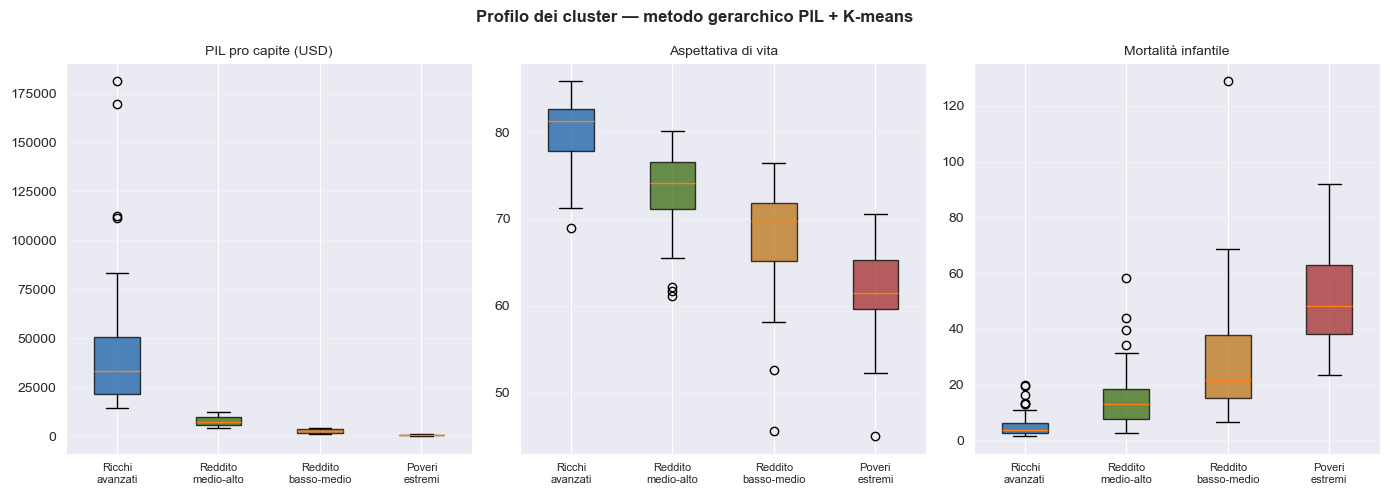

✓ Salvato: cluster_profiles_hierarchical.png


In [26]:
# %% [8] VISUALIZZAZIONE PROFILI CLUSTER
# -----------------------------------------------------------------------------
fig, axes = plt.subplots(1, 3, figsize=(14, 5))

vars_plot = [
    ('gdp_per_capita',   'PIL pro capite (USD)'),
    ('life_expectancy',  'Aspettativa di vita'),
    ('infant_mortality', 'Mortalità infantile'),
]

for ax, (var, title) in zip(axes, vars_plot):
    data = [latest[latest['cluster_wb'] == label][var].dropna().values
            for label in CLUSTER_ORDER]
    colors = [CLUSTER_COLORS[l] for l in CLUSTER_ORDER]
    bp = ax.boxplot(data, patch_artist=True)
    for patch, color in zip(bp['boxes'], colors):
        patch.set_facecolor(color)
        patch.set_alpha(0.75)
    ax.set_xticklabels([l.replace(' ', '\n') for l in CLUSTER_ORDER], fontsize=8)
    ax.set_title(title, fontsize=10)
    ax.grid(True, alpha=0.3, axis='y')

plt.suptitle('Profilo dei cluster — metodo gerarchico PIL + K-means',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('cluster_profiles_hierarchical.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ Salvato: cluster_profiles_hierarchical.png")

In [27]:

# -----------------------------------------------------------------------------
print()
print("=" * 60)
print("NOTA METODOLOGICA — DA INCLUDERE NELLA TESI")
print("=" * 60)
print("""
La classificazione dei paesi in cluster socioeconomici segue
un approccio gerarchico in due stadi:

STADIO 1 — Soglie Banca Mondiale (2023):
  I paesi vengono prima assegnati a quattro fasce di reddito
  in base al PIL pro capite (USD correnti):
  • Alto reddito:        > $13.845  → "Ricchi avanzati"
  • Medio-alto reddito:  $4.466–$13.845 → "Reddito medio-alto"
  • Medio-basso reddito: $1.136–$4.465  → "Reddito basso-medio"
  • Basso reddito:       < $1.136   → "Poveri estremi"

  Fonte: World Bank Country and Lending Groups, 2023.
  (https://datahelpdesk.worldbank.org/knowledgebase/articles/906519)

STADIO 2 — K-means per paesi senza PIL:
  I paesi privi di dati PIL vengono assegnati al cluster più
  vicino per distanza euclidea sui quattro indicatori proxy
  (aspettativa di vita, urbanizzazione, mortalità infantile,
  iscrizione scolastica), normalizzati con z-score.

Questo approccio garantisce:
  1. Coerenza con le classificazioni internazionali standard
  2. Interpretabilità economica dei cluster
  3. Robustezza rispetto agli outlier su indicatori secondari
     (es. paesi con alta urbanizzazione ma PIL basso)
""")



NOTA METODOLOGICA — DA INCLUDERE NELLA TESI

La classificazione dei paesi in cluster socioeconomici segue
un approccio gerarchico in due stadi:

STADIO 1 — Soglie Banca Mondiale (2023):
  I paesi vengono prima assegnati a quattro fasce di reddito
  in base al PIL pro capite (USD correnti):
  • Alto reddito:        > $13.845  → "Ricchi avanzati"
  • Medio-alto reddito:  $4.466–$13.845 → "Reddito medio-alto"
  • Medio-basso reddito: $1.136–$4.465  → "Reddito basso-medio"
  • Basso reddito:       < $1.136   → "Poveri estremi"

  Fonte: World Bank Country and Lending Groups, 2023.
  (https://datahelpdesk.worldbank.org/knowledgebase/articles/906519)

STADIO 2 — K-means per paesi senza PIL:
  I paesi privi di dati PIL vengono assegnati al cluster più
  vicino per distanza euclidea sui quattro indicatori proxy
  (aspettativa di vita, urbanizzazione, mortalità infantile,
  iscrizione scolastica), normalizzati con z-score.

Questo approccio garantisce:
  1. Coerenza con le classificazioni inte

In [28]:
# %% [9] MERGE CON IL DATASET OLIMPICO COMPLETO
# -----------------------------------------------------------------------------
# Aggiungiamo il cluster a tutte le edizioni del dataset principale
# (non solo all'ultima) usando il paese come chiave

cluster_map = latest[['country', 'cluster_wb']].drop_duplicates()
df_merged = df.merge(cluster_map, on='country', how='left')

n_unmatched = df_merged['cluster_wb'].isna().sum()
print(f"\nRighe con cluster assegnato: {df_merged['cluster_wb'].notna().sum():,}")
print(f"Righe senza cluster (paesi con dati insufficienti): {n_unmatched:,}")

# Salva il dataset finale
df_merged.to_csv('olympics_with_clusters.csv', index=False)
print("\n✓ Salvato: olympics_with_clusters.csv")
print("   → questo è il file da usare per l'analisi degli sport per cluster")


Righe con cluster assegnato: 3,215
Righe senza cluster (paesi con dati insufficienti): 153

✓ Salvato: olympics_with_clusters.csv
   → questo è il file da usare per l'analisi degli sport per cluster


## Verifica puntuale su alcuni paesi di controllo

In [29]:
# =============================================================================
# SPOT-CHECK — VERIFICA SU PAESI "DI CONTROLLO"
# =============================================================================
# Prima di fidarci della classificazione, verifichiamo alcuni paesi per cui
# conosciamo la risposta attesa (es. Monaco = tra i più ricchi al mondo,
# Somalia = tra i più poveri). Se il cluster li inverte, è quasi certamente
# un problema di dati mancanti o di codice paese nel merge, non un difetto
# del metodo di clustering in sé.

CONTROL_COUNTRIES = ['somalia', 'monaco', 'norway', 'luxembourg', 'congo']
mask_control = latest['country'].str.lower().str.contains(
    '|'.join(CONTROL_COUNTRIES), na=False
)

cols_check = ['noc', 'country', 'gdp_per_capita', 'life_expectancy',
              'urbanization_pct', 'infant_mortality',
              'primary_school_enrollment', 'population', 'cluster_wb']

print("=== PAESI DI CONTROLLO ===")
print(latest.loc[mask_control, cols_check].to_string(index=False))

=== PAESI DI CONTROLLO ===
noc                           country  gdp_per_capita  life_expectancy  urbanization_pct  infant_mortality  primary_school_enrollment  population          cluster_wb
COD Congo, Democratic Republic of the      478.247854        59.686000         42.302794            55.700                 111.488670 88508724.75      Poveri estremi
COG                             Congo     2371.899796        63.934500         63.391770            33.200                  87.462112  5418331.50 Reddito basso-medio
LUX                        Luxembourg   111678.979000        82.428659         92.390503             2.075                  97.455542   601575.25     Ricchi avanzati
MCO                            Monaco   181578.307530        85.935750        100.000000             2.675                 142.419937    37804.25     Ricchi avanzati
NOR                            Norway    76555.657765        82.683537         82.097194             2.050                  99.186377  5292824.

In [30]:
# %% [D1] QUANTI INDICATORI MANCANO, PER I PAESI DI CONTROLLO?
# -----------------------------------------------------------------------------
INDICATOR_COLS = ['gdp_per_capita', 'life_expectancy', 'urbanization_pct',
                  'infant_mortality', 'primary_school_enrollment']

print("=== VALORI MANCANTI (True = mancante) ===")
print(latest.loc[mask_control].set_index('country')[INDICATOR_COLS]
      .isna().to_string())

# Se un paese ha TUTTI gli indicatori mancanti, l'imputer lo riempie con
# la mediana globale di ciascun indicatore: il paese finisce per assomigliare
# al "paese mediano" del dataset, indipendentemente dalla sua vera situazione.
n_all_missing = latest[INDICATOR_COLS].isna().all(axis=1).sum()
print(f"\nPaesi nel dataset con TUTTI e {len(INDICATOR_COLS)} gli indicatori "
      f"mancanti: {n_all_missing}")
if n_all_missing > 0:
    print(latest[latest[INDICATOR_COLS].isna().all(axis=1)]
          [['noc', 'country', 'cluster_wb']].to_string(index=False))

=== VALORI MANCANTI (True = mancante) ===
                                   gdp_per_capita  life_expectancy  urbanization_pct  infant_mortality  primary_school_enrollment
country                                                                                                                          
Congo, Democratic Republic of the           False            False             False             False                      False
Congo                                       False            False             False             False                      False
Luxembourg                                  False            False             False             False                      False
Monaco                                      False            False             False             False                      False
Norway                                      False            False             False             False                      False
Somalia                                     Fals

In [31]:
# %% [D2] IL CODICE PAESE È QUELLO GIUSTO?
# -----------------------------------------------------------------------------
# Controllo rapido: Monaco dovrebbe avere noc='MCO' (ISO3) — se il merge tra
# le fonti usa il codice IOC ('MON') da qualche parte senza la conversione,
# le sue righe possono finire scollegate dai dati economici corretti, o unite
# a un altro paese per errore. Stessa logica per qualunque altro mismatch.
for _, row in latest.loc[mask_control, ['noc', 'country']].iterrows():
    print(f"{row['country']:35s} -> noc = {row['noc']}")

Congo, Democratic Republic of the   -> noc = COD
Congo                               -> noc = COG
Luxembourg                          -> noc = LUX
Monaco                              -> noc = MCO
Norway                              -> noc = NOR
Somalia                             -> noc = SOM


## Stadio 2 — Robustness check: clustering multivariato (K-means)

Verifica se la sola classificazione per PIL cattura adeguatamente la struttura multidimensionale dello sviluppo, rifacendo il clustering in modo puramente data-driven su tutti e cinque gli indicatori insieme (K-means, k=4, standardizzazione z-score, imputazione mediana).

In [32]:
# =============================================================================
# ROBUSTNESS CHECK — CLUSTERING MULTIVARIATO vs SOGLIE BANCA MONDIALE
# =============================================================================
# La classificazione principale (soglie Banca Mondiale sul solo PIL pro
# capite) è interpretabile e citabile, ma ignora le altre dimensioni dello
# sviluppo. Qui rifacciamo il clustering in modo puramente data-driven,
# usando TUTTI gli indicatori socioeconomici insieme (K-means multivariato),
# e confrontiamo il risultato con la classificazione a soglie — senza
# sostituirla: resta quella usata nel resto del notebook.
# =============================================================================
MULTI_VARS = ['gdp_per_capita', 'life_expectancy', 'urbanization_pct',
              'infant_mortality', 'primary_school_enrollment']

X_multi = latest[MULTI_VARS].copy()
print(f"Paesi con almeno 3 indicatori su {len(MULTI_VARS)} disponibili: "
      f"{X_multi.dropna(thresh=3).shape[0]} (su {len(X_multi)})")

imp_multi = SimpleImputer(strategy='median')
X_multi_imp = imp_multi.fit_transform(X_multi)

scaler_multi = StandardScaler()
X_multi_sc = scaler_multi.fit_transform(X_multi_imp)

Paesi con almeno 3 indicatori su 5 disponibili: 206 (su 206)


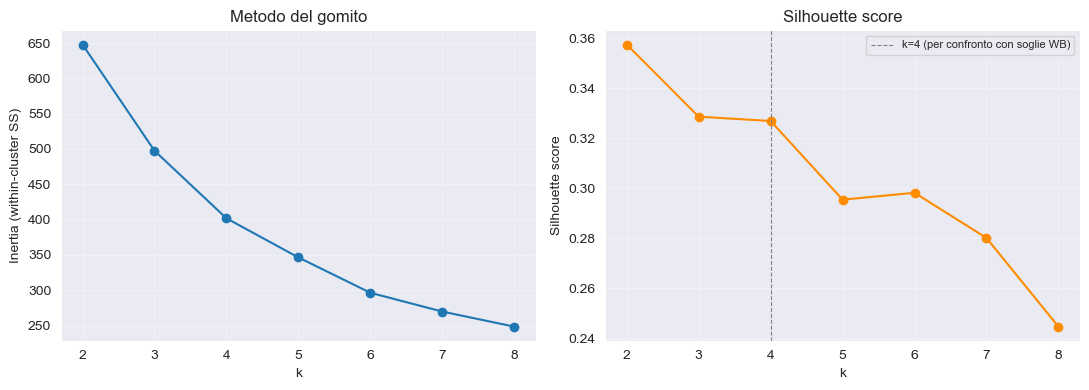

✓ Salvato: elbow_silhouette_multivariato.png

k con silhouette più alto: 2 (silhouette = 0.357)
Eseguiamo comunque anche k=4 qui sotto, per un confronto diretto con
le 4 fasce della classificazione a soglie WB (indipendentemente da
quale k risulti "ottimale" secondo questi criteri).


In [33]:
# %% [R1] SCELTA DI K — ELBOW E SILHOUETTE
# -----------------------------------------------------------------------------
from sklearn.metrics import silhouette_score

k_range = range(2, 9)
inertias = []
silhouettes = []

for k in k_range:
    km = KMeans(n_clusters=k, n_init=10, random_state=42)
    labels_k = km.fit_predict(X_multi_sc)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_multi_sc, labels_k))

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].plot(list(k_range), inertias, marker='o')
axes[0].set_xlabel('k')
axes[0].set_ylabel('Inertia (within-cluster SS)')
axes[0].set_title('Metodo del gomito')
axes[0].grid(alpha=0.3)

axes[1].plot(list(k_range), silhouettes, marker='o', color='darkorange')
axes[1].set_xlabel('k')
axes[1].set_ylabel('Silhouette score')
axes[1].set_title('Silhouette score')
axes[1].axvline(4, color='gray', linestyle='--', linewidth=0.8,
                label='k=4 (per confronto con soglie WB)')
axes[1].legend(fontsize=8)
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('elbow_silhouette_multivariato.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ Salvato: elbow_silhouette_multivariato.png")

best_k = list(k_range)[int(np.argmax(silhouettes))]
print(f"\nk con silhouette più alto: {best_k} (silhouette = {max(silhouettes):.3f})")
print("Eseguiamo comunque anche k=4 qui sotto, per un confronto diretto con")
print("le 4 fasce della classificazione a soglie WB (indipendentemente da")
print("quale k risulti \"ottimale\" secondo questi criteri).")

In [34]:
# %% [R2] CLUSTERING MULTIVARIATO CON k=4 — CONFRONTO DIRETTO CON LE SOGLIE WB
# -----------------------------------------------------------------------------
km4 = KMeans(n_clusters=4, n_init=10, random_state=42)

latest_multi = latest.dropna(subset=['cluster_wb']).copy()
X_compare_imp = imp_multi.transform(latest_multi[MULTI_VARS])
X_compare_sc = scaler_multi.transform(X_compare_imp)

latest_multi['cluster_multivariato'] = km4.fit_predict(X_compare_sc)

# Rinominiamo i cluster K-means in base al PIL medio, così l'ordine è
# comparabile con CLUSTER_ORDER (dal più ricco al più povero)
centroid_gdp = (
    latest_multi.groupby('cluster_multivariato')['gdp_per_capita']
    .mean()
    .sort_values(ascending=False)  # PIL decrescente, coerente con CLUSTER_ORDER
    # (che parte da 'Ricchi avanzati')
)
rank_map = {old: CLUSTER_ORDER[i] for i, old in enumerate(centroid_gdp.index)}
latest_multi['cluster_multivariato_label'] = latest_multi['cluster_multivariato'].map(rank_map)

print(latest_multi[['country', 'cluster_wb', 'cluster_multivariato_label']]
      .head(10).to_string(index=False))

             country          cluster_wb cluster_multivariato_label
               Aruba     Ricchi avanzati         Reddito medio-alto
         Afghanistan      Poveri estremi        Reddito basso-medio
              Angola Reddito basso-medio        Reddito basso-medio
             Albania  Reddito medio-alto         Reddito medio-alto
             Andorra     Ricchi avanzati            Ricchi avanzati
United Arab Emirates     Ricchi avanzati            Ricchi avanzati
           Argentina  Reddito medio-alto         Reddito medio-alto
             Armenia Reddito basso-medio         Reddito medio-alto
      American Samoa  Reddito medio-alto         Reddito medio-alto
 Antigua and Barbuda     Ricchi avanzati         Reddito medio-alto


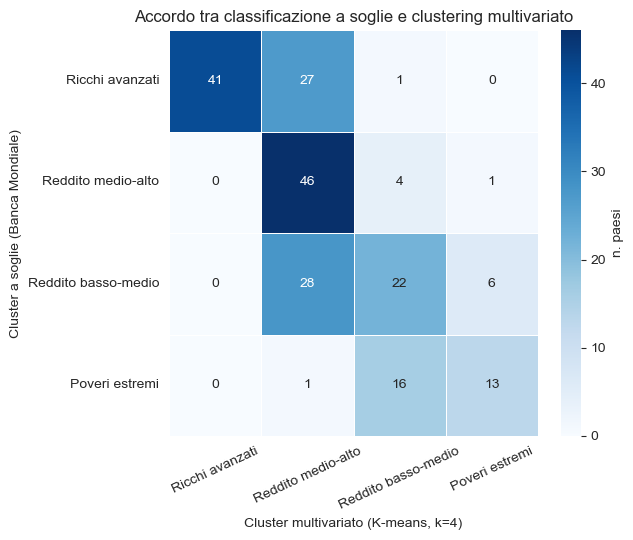

✓ Salvato: contingenza_wb_vs_multivariato.png

Adjusted Rand Index: 0.261
Accordo sulla diagonale (stessa fascia in entrambi i metodi): 59.2%


In [35]:
# %% [R3] ACCORDO TRA I DUE METODI — MATRICE DI CONTINGENZA E ARI
# -----------------------------------------------------------------------------
from sklearn.metrics import adjusted_rand_score

contingency = pd.crosstab(
    latest_multi['cluster_wb'], latest_multi['cluster_multivariato_label']
).reindex(index=CLUSTER_ORDER, columns=CLUSTER_ORDER, fill_value=0)

fig, ax = plt.subplots(figsize=(6.5, 5.5))
sns.heatmap(contingency, annot=True, fmt='d', cmap='Blues', linewidths=0.5, ax=ax,
            cbar_kws={'label': 'n. paesi'})
ax.set_xlabel('Cluster multivariato (K-means, k=4)')
ax.set_ylabel('Cluster a soglie (Banca Mondiale)')
ax.set_title('Accordo tra classificazione a soglie e clustering multivariato', fontsize=12)
ax.tick_params(axis='x', rotation=25)
ax.tick_params(axis='y', rotation=0)
plt.tight_layout()
plt.savefig('contingenza_wb_vs_multivariato.png', dpi=150, bbox_inches='tight')
plt.show()

ari = adjusted_rand_score(latest_multi['cluster_wb'], latest_multi['cluster_multivariato_label'])
agreement_pct = (np.diag(contingency.values).sum() / contingency.values.sum()) * 100

print("✓ Salvato: contingenza_wb_vs_multivariato.png")
print(f"\nAdjusted Rand Index: {ari:.3f}")
print(f"Accordo sulla diagonale (stessa fascia in entrambi i metodi): {agreement_pct:.1f}%")

In [36]:
# %% [R4] CHI SONO I PAESI IN DISACCORDO?
# -----------------------------------------------------------------------------
disagreement = latest_multi[
    latest_multi['cluster_wb'] != latest_multi['cluster_multivariato_label']
    ][['country', 'gdp_per_capita', 'life_expectancy', 'infant_mortality',
       'cluster_wb', 'cluster_multivariato_label']].sort_values('gdp_per_capita')

print(f"Paesi classificati diversamente dai due metodi: {len(disagreement)} "
      f"({len(disagreement) / len(latest_multi) * 100:.1f}%)")
print()
print(disagreement.to_string(index=False))

Paesi classificati diversamente dai due metodi: 84 (40.8%)

                          country  gdp_per_capita  life_expectancy  infant_mortality          cluster_wb cluster_multivariato_label
                          Burundi      239.742708        61.530000            37.775      Poveri estremi        Reddito basso-medio
Congo, Democratic Republic of the      478.247854        59.686000            55.700      Poveri estremi        Reddito basso-medio
                       Madagascar      486.528397        63.464750            43.825      Poveri estremi        Reddito basso-medio
                       Mozambique      487.257027        60.424750            50.925      Poveri estremi        Reddito basso-medio
                      Afghanistan      508.872928        62.609000            59.225      Poveri estremi        Reddito basso-medio
                           Malawi      515.091874        64.134000            38.475      Poveri estremi        Reddito basso-medio
                

In [37]:
# %% [R5] NOTA METODOLOGICA — DA INCLUDERE NELLA TESI
# -----------------------------------------------------------------------------
print("""
============================================================
NOTA METODOLOGICA — ROBUSTNESS CHECK DEL CLUSTERING
============================================================
La classificazione principale usata in questa analisi si basa
sulle soglie di reddito della Banca Mondiale (2023), applicate
al solo PIL pro capite. È una scelta intenzionale: un criterio
esterno, citabile e stabile, che rende le etichette dei cluster
("Ricchi avanzati", ecc.) direttamente interpretabili.

Come verifica di robustezza, il clustering è stato rifatto in
modo puramente data-driven (K-means su tutti gli indicatori
socioeconomici standardizzati, k=4 per un confronto diretto).
L'Adjusted Rand Index e la percentuale di paesi sulla diagonale
della matrice di contingenza misurano quanto la sola dimensione
"reddito" catturi la struttura multidimensionale dello sviluppo
implicita nell'insieme degli indicatori. Un accordo alto valida
l'uso delle soglie WB per la loro interpretabilità; un accordo
basso è di per sé un risultato da discutere (il PIL pro capite
da solo non basta a descrivere lo sviluppo socioeconomico).
""")


NOTA METODOLOGICA — ROBUSTNESS CHECK DEL CLUSTERING
La classificazione principale usata in questa analisi si basa
sulle soglie di reddito della Banca Mondiale (2023), applicate
al solo PIL pro capite. È una scelta intenzionale: un criterio
esterno, citabile e stabile, che rende le etichette dei cluster
("Ricchi avanzati", ecc.) direttamente interpretabili.

Come verifica di robustezza, il clustering è stato rifatto in
modo puramente data-driven (K-means su tutti gli indicatori
socioeconomici standardizzati, k=4 per un confronto diretto).
L'Adjusted Rand Index e la percentuale di paesi sulla diagonale
della matrice di contingenza misurano quanto la sola dimensione
"reddito" catturi la struttura multidimensionale dello sviluppo
implicita nell'insieme degli indicatori. Un accordo alto valida
l'uso delle soglie WB per la loro interpretabilità; un accordo
basso è di per sé un risultato da discutere (il PIL pro capite
da solo non basta a descrivere lo sviluppo socioeconomico).



## Il clustering multivariato diventa il cluster di riferimento

Da qui in avanti, l'etichetta di cluster socioeconomico usata in **tutte** le
analisi successive — le analisi sport (con cluster dinamico anno per anno),
la mobilità dei cluster nel tempo, la regressione e i modelli non lineari
(Random Forest / Gradient Boosting) — è quella del
**clustering multivariato** (K-means su PIL pro capite, aspettativa di vita,
urbanizzazione, mortalità infantile e iscrizione scolastica primaria, k=4),
non più le sole soglie di reddito della Banca Mondiale sul PIL pro capite.

Motivazione: le soglie WB catturano una sola dimensione (il reddito); il
clustering multivariato è puramente data-driven e tiene conto anche di
salute, urbanizzazione e istruzione, offrendo una segmentazione più ricca dei
paesi — ed è il criterio la cui coerenza con le soglie abbiamo appena
verificato nel robustness check qui sopra (Adjusted Rand Index e matrice di
contingenza).

Le etichette restano le stesse quattro fasce (`Ricchi avanzati`, `Reddito
medio-alto`, `Reddito basso-medio`, `Poveri estremi`), assegnate in base al
PIL medio del cluster multivariato (decrescente), cosi' tutte le celle
successive che già leggevano `cluster_label` / `cluster_wb` da
`olympics_with_clusters.csv` continuano a funzionare senza modifiche: la
colonna `cluster_label` viene semplicemente ricalcolata qui con l'etichetta
multivariata. La classificazione a soglie resta comunque nel file, nella
colonna `cluster_wb`, come riferimento per il confronto già fatto sopra.

In [38]:
# %% [R6] PROPAGAZIONE DEL CLUSTER MULTIVARIATO A TUTTO IL DATASET (TUTTE LE EDIZIONI)
# -----------------------------------------------------------------------------
# Finora il clustering multivariato ('cluster_multivariato_label') e' stato
# calcolato solo sullo snapshot 'latest_multi' (un record per paese), per il
# robustness check. Da qui in avanti lo usiamo come cluster PRINCIPALE:
# lo riportiamo quindi su ogni riga (paese-edizione) del dataset, esattamente
# come gia' fatto per il cluster a soglie in precedenza — cosi' sport,
# mobilita', regressione e modelli non lineari lo useranno automaticamente.
#
# Merge a tre livelli (noc -> country -> country normalizzato), perche' il
# dataset ha piu' convenzioni di codice/nome paese miste (visto anche nello
# spot-check qui sotto per i Paesi Bassi: 'latest_multi' li registra come
# noc='NLD', country='Netherlands, Kingdom of the' — nome ufficiale in stile
# Banca Mondiale — mentre il resto del dataset usa noc='NED',
# country='Netherlands'):
#   1) noc esatto
#   2) country esatto (fallback)
#   3) country "normalizzato" — solo la parte prima della virgola, per
#      recuperare i nomi ufficiali stile Banca Mondiale (es. "Netherlands,
#      Kingdom of the" -> "Netherlands", "Korea, Republic of" -> "Korea")

def normalize_country(name):
    if pd.isna(name):
        return name
    return str(name).split(',')[0].strip()

cluster_map_multi_noc = (
    latest_multi[['noc', 'cluster_multivariato_label']]
    .rename(columns={'cluster_multivariato_label': 'cluster_label'})
    .drop_duplicates(subset='noc')
)
cluster_map_multi_country = (
    latest_multi[['country', 'cluster_multivariato_label']]
    .rename(columns={'cluster_multivariato_label': 'cluster_label'})
    .drop_duplicates(subset='country')
)
cluster_map_multi_country_norm = (
    latest_multi.assign(country_norm=latest_multi['country'].apply(normalize_country))
    [['country_norm', 'cluster_multivariato_label']]
    .rename(columns={'cluster_multivariato_label': 'cluster_label'})
    .drop_duplicates(subset='country_norm')
)

# df_merged contiene già 'cluster_wb' (la classificazione a soglie, tenuta
# come riferimento); sovrascriviamo/aggiungiamo 'cluster_label' e 'cluster'
# con l'etichetta multivariata.
df_merged = df_merged.drop(columns=['cluster_label', 'cluster'], errors='ignore')
df_merged = df_merged.merge(cluster_map_multi_noc, on='noc', how='left')
n_after_noc = df_merged['cluster_label'].notna().sum()

# Fallback 1: nome paese esatto
still_missing = df_merged['cluster_label'].isna()
if still_missing.any():
    fallback = df_merged.loc[still_missing, ['country']].merge(
        cluster_map_multi_country, on='country', how='left'
    )
    df_merged.loc[still_missing, 'cluster_label'] = fallback['cluster_label'].values
n_after_country = df_merged['cluster_label'].notna().sum()

# Fallback 2: nome paese normalizzato (senza suffisso ufficiale dopo la virgola)
still_missing2 = df_merged['cluster_label'].isna()
if still_missing2.any():
    fallback2 = (
        df_merged.loc[still_missing2, ['country']]
        .assign(country_norm=lambda d: d['country'].apply(normalize_country))
        .merge(cluster_map_multi_country_norm, on='country_norm', how='left')
    )
    df_merged.loc[still_missing2, 'cluster_label'] = fallback2['cluster_label'].values
n_after_norm = df_merged['cluster_label'].notna().sum()

cluster_num_map = {label: i for i, label in enumerate(CLUSTER_ORDER)}
df_merged['cluster'] = df_merged['cluster_label'].map(cluster_num_map)

print(f"Dataset finale: {len(df_merged):,} righe")
print(f"Cluster assegnato via 'noc':                        {n_after_noc:,}")
print(f"Cluster assegnato dopo fallback su 'country':        {n_after_country:,}")
print(f"Cluster assegnato dopo fallback su 'country' normal.: {n_after_norm:,} "
      f"({n_after_norm / len(df_merged) * 100:.1f}%)")
print()
print("=== DISTRIBUZIONE CLUSTER MULTIVARIATO NEL DATASET FINALE ===")
print(df_merged['cluster_label'].value_counts().reindex(CLUSTER_ORDER).to_string())

Dataset finale: 3,368 righe
Cluster assegnato via 'noc':                        3,090
Cluster assegnato dopo fallback su 'country':        3,278
Cluster assegnato dopo fallback su 'country' normal.: 3,293 (97.8%)

=== DISTRIBUZIONE CLUSTER MULTIVARIATO NEL DATASET FINALE ===
cluster_label
Ricchi avanzati         674
Reddito medio-alto     1655
Reddito basso-medio     650
Poveri estremi          314


In [39]:
# %% [R7] SALVATAGGIO — IL CLUSTER MULTIVARIATO DIVENTA IL CLUSTER DI RIFERIMENTO
# -----------------------------------------------------------------------------
# Sovrascriviamo olympics_with_clusters.csv: 'cluster_label' (e 'cluster')
# sono ora basati sul clustering multivariato; 'cluster_wb' resta nel file
# come riferimento per il confronto gia' fatto nel robustness check.
df_merged.to_csv('olympics_with_clusters.csv', index=False)
print("✓ Salvato: olympics_with_clusters.csv")
print("  → 'cluster_label' = clustering multivariato (usato in sport, mobilità, regressione, RF/GBM)")
print("  → 'cluster_wb'    = classificazione a soglie Banca Mondiale (solo riferimento)")

✓ Salvato: olympics_with_clusters.csv
  → 'cluster_label' = clustering multivariato (usato in sport, mobilità, regressione, RF/GBM)
  → 'cluster_wb'    = classificazione a soglie Banca Mondiale (solo riferimento)


### Spot-check — perché i Paesi Bassi (NED) restano senza cluster?

A differenza di Danimarca e Svizzera (rientrate col fallback su `country`), i
Paesi Bassi risultano ancora senza cluster anche dopo il fallback. Verifichiamo
riga per riga cosa succede nelle tre tabelle chiave: `latest` (dove nasce il
cluster), `latest_multi` (da cui viene propagato) e `df_merged` (dove viene
applicato) — cercando sia per nome paese che per codice NOC/ISO3, per non perdere
eventuali varianti di scrittura o di codice.

In [40]:
# %% [R6bis] SPOT-CHECK — PAESI BASSI SENZA CLUSTER
# -----------------------------------------------------------------------------
mask_country = lambda s: s.astype(str).str.contains('Nether', case=False, na=False)
mask_noc = lambda s: s.astype(str).str.upper().isin(['NED', 'NLD'])

print("=== In 'latest' (snapshot per paese, prima del clustering) ===")
print(latest[mask_country(latest['country']) | mask_noc(latest['noc'])]
      [['noc', 'country', 'gdp_per_capita', 'life_expectancy', 'urbanization_pct',
        'infant_mortality', 'primary_school_enrollment', 'cluster_wb']]
      .to_string(index=False))

print("\n=== In 'latest_multi' (usato per propagare il cluster multivariato) ===")
print(latest_multi[mask_country(latest_multi['country']) | mask_noc(latest_multi['noc'])]
      [['noc', 'country', 'cluster_multivariato_label']]
      .to_string(index=False))

print("\n=== In 'df_merged' PRIMA del merge (valori distinti di noc/country) ===")
raw_rows = df[mask_country(df['country']) | mask_noc(df['noc'])]
print(raw_rows[['noc', 'country', 'year']].drop_duplicates(subset=['noc', 'country']).to_string(index=False))

print("\n=== In 'df_merged' DOPO il merge (cluster_label assegnato?) ===")
print(df_merged[mask_country(df_merged['country']) | mask_noc(df_merged['noc'])]
      [['noc', 'country', 'year', 'cluster_label']]
      .drop_duplicates(subset=['noc', 'country'])
      .to_string(index=False))

=== In 'latest' (snapshot per paese, prima del clustering) ===
noc                     country  gdp_per_capita  life_expectancy  urbanization_pct  infant_mortality  primary_school_enrollment      cluster_wb
NLD Netherlands, Kingdom of the    50958.047159        81.811585         92.049586               3.5                 104.964952 Ricchi avanzati

=== In 'latest_multi' (usato per propagare il cluster multivariato) ===
noc                     country cluster_multivariato_label
NLD Netherlands, Kingdom of the            Ricchi avanzati

=== In 'df_merged' PRIMA del merge (valori distinti di noc/country) ===
noc                     country  year
NED                 Netherlands  1964
AHO        Netherlands Antilles  1988
NLD Netherlands, Kingdom of the  1964

=== In 'df_merged' DOPO il merge (cluster_label assegnato?) ===
noc                     country  year   cluster_label
NED                 Netherlands  1964 Ricchi avanzati
AHO        Netherlands Antilles  1988             NaN
NLD Ne